# Baseline Regression — Linear Regression

Goal: establish a **reference point** for predicting `total_count` (hourly bike rentals). The model has to be the simplest sensible thing — `sklearn.linear_model.LinearRegression` on a minimally engineered feature set — so that everything more complex can be measured against it.

This notebook is intentionally *not* about getting the best score. Feature engineering, non-linear models, and any subsequent integration into the Dagster pipeline live outside this notebook. The deliverables here are:
- A clean train/test split appropriate for time-series data.
- Headline regression metrics (RMSE, MAE, R²) on the held-out test set.
- Residual diagnostics that confirm/refute the modelling weaknesses predicted by the EDA.

All modelling decisions follow directly from the takeaways at the bottom of [`01_eda.ipynb`](./01_eda.ipynb).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

## 1. Load data and select features

Following the EDA takeaways:

- **Target** = `total_count`.
- **Drop** `registered_count` and `direct_count` (their sum *is* the target — keeping them would leak it).
- **Drop** `datetime` and `date` (raw timestamps — a linear model cannot use them directly; the derived columns `hour`, `day`, `is_weekend` already encode the useful signal).
- **Drop** `perceived_temperature_c` (0.99 correlated with `temperature_c`; keeping both inflates coefficient variance without adding information).
- **Drop** `time_of_day` — it is a coarse bucketing of `hour` and the two correlate at 0.97. Same multicollinearity problem as the two temperature columns: keeping both splits the time-of-day signal across two correlated coefficients without adding information. We keep `hour` (finer-grained) and drop `time_of_day`.
- **Keep** the rest. `conditions` is the only categorical column and gets one-hot encoded; everything else is numeric or boolean and feeds the linear model directly.

In [2]:
df = pd.read_csv(
    "../data/output-local/final_dataset.csv",
    parse_dates=["datetime", "date"],
).sort_values("datetime").reset_index(drop=True)

TARGET = "total_count"
DROP = ["datetime", "date", "registered_count", "direct_count",
        "perceived_temperature_c", "time_of_day"]

numeric_features = ["hour", "day", "is_weekend", "is_holiday",
                    "temperature_c", "humidity", "windspeed_kmh"]
categorical_features = ["conditions"]

X = df[numeric_features + categorical_features].copy()
X["is_weekend"] = X["is_weekend"].astype(int)
X["is_holiday"] = X["is_holiday"].astype(int)
y = df[TARGET]

print(f"X shape: {X.shape}, y shape: {y.shape}")
X.head()

X shape: (17379, 8), y shape: (17379,)


,hour,day,is_weekend,is_holiday,temperature_c,humidity,windspeed_kmh,conditions
0,0,5,1,0,3.3,81.0,0.0,clear
1,1,5,1,0,2.3,80.0,0.0,clear
2,2,5,1,0,2.3,80.0,0.0,clear
3,3,5,1,0,3.3,75.0,0.0,clear
4,4,5,1,0,3.3,75.0,0.0,clear


## 2. Time-aware train/test split

A standard random shuffle is wrong for this dataset. From the EDA we saw clear year-over-year growth and seasonal cycling — randomly sampling test rows would let the model peek at e.g. June-2012 demand while training on neighbouring hours from the same week, vastly overstating real-world performance.

We instead **split chronologically**: the first 80% of hours go to training, the last 20% to test. This emulates how the model would actually be used (predict future hours given past data), and it is honest about the weakest part of the feature set — the lack of any explicit year/trend feature.

We deliberately do not use `train_test_split(shuffle=False)` from `sklearn.model_selection` here to keep the slicing logic visible.

In [3]:
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {len(X_train):>6} rows  | {df['datetime'].iloc[0]}  →  {df['datetime'].iloc[split_idx - 1]}")
print(f"Test:  {len(X_test):>6} rows  | {df['datetime'].iloc[split_idx]}  →  {df['datetime'].iloc[-1]}")

Train:  13903 rows  | 2011-01-01 00:00:00  →  2012-08-07 11:00:00
Test:    3476 rows  | 2012-08-07 12:00:00  →  2012-12-31 23:00:00


## 3. Preprocessing + model pipeline

A `ColumnTransformer` handles one-hot encoding of `conditions` and passes the numeric columns through unchanged. We do **not** scale numeric features — plain `LinearRegression` (ordinary least squares) is scale-invariant; scaling would only matter if we added regularisation (Ridge/Lasso) in the improvement step.

`handle_unknown="ignore"` on the encoder is defensive: if a future deployment sees a weather condition not present in training (e.g. a `snow` category appearing in a later year), the row is encoded as all-zeros for that column rather than crashing.

In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    remainder="passthrough",
)

model = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", LinearRegression()),
])
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

## 4. Train and evaluate

Three metrics, each measuring something different:
- **RMSE** — same units as the target (rentals/hour). Penalises large errors more.
- **MAE** — same units, robust to outliers, easy to explain ("on average we're off by N rentals").
- **R²** — unitless, says how much of the variance the model explains relative to predicting the mean. Useful for comparing models, not for absolute claims.

In [5]:
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

def report(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name:>5} | RMSE={rmse:7.2f} | MAE={mae:7.2f} | R²={r2:6.3f}")
    return {"rmse": rmse, "mae": mae, "r2": r2}

train_metrics = report("Train", y_train, y_pred_train)
test_metrics = report("Test", y_test, y_pred_test)

Train | RMSE= 134.23 | MAE=  98.65 | R²= 0.354
 Test | RMSE= 199.76 | MAE= 134.91 | R²= 0.179


## 5. Coefficients

Reading the fitted coefficients is a quick sanity check — directions and rough magnitudes should match what we saw in the EDA. Coefficients are reported on the *unscaled* features, so they are not directly comparable across features (a 1°C change in temperature is not interchangeable with a 1-step change in `is_weekend`), but the sign of each one should make sense.

In [6]:
feature_names = model.named_steps["preprocess"].get_feature_names_out()
coefs = pd.Series(model.named_steps["regressor"].coef_, index=feature_names).sort_values()
intercept = model.named_steps["regressor"].intercept_
print(f"Intercept: {intercept:.2f}")
coefs

Intercept: 104.15


cat__conditions_light_rain   -32.294286
remainder__is_holiday        -24.902280
cat__conditions_clear         -6.738036
remainder__is_weekend         -2.060964
remainder__humidity           -1.782262
remainder__windspeed_kmh       0.240030
remainder__day                 0.449975
cat__conditions_clouds         2.102649
remainder__temperature_c       6.726940
remainder__hour                7.018599
cat__conditions_heavy_rain    36.929673
dtype: float64

**Expected sign check.** With `time_of_day` dropped, `hour` is the sole time-of-day feature and should now carry a positive coefficient — mean demand rises from the 5 AM trough through the day. `temperature_c` should be positive, `humidity` negative, `is_holiday` negative, and `conditions=clear` / `clouds` should outrank `light_rain` and `heavy_rain` (with the caveat that `heavy_rain` is fit on only 3 rows and its coefficient is essentially noise).

If any of these signs are wildly off, that points at a data or encoding bug, not a model weakness.

## 6. Residual diagnostics

Three plots. Each one is designed to expose a specific failure mode predicted in [`01_eda.ipynb`](./01_eda.ipynb):

1. **Predicted vs actual** — if the cloud doesn't sit on the y=x line, the model is systematically biased.
2. **Predictions vs actuals on a one-week slice of the test set** — does the model track the daily commute peaks, or does it smear them?
3. **Residuals vs `hour`** — if the linear baseline cannot model the bimodal weekday curve (Section 3 of the EDA), residuals will fan out at the commute hours.

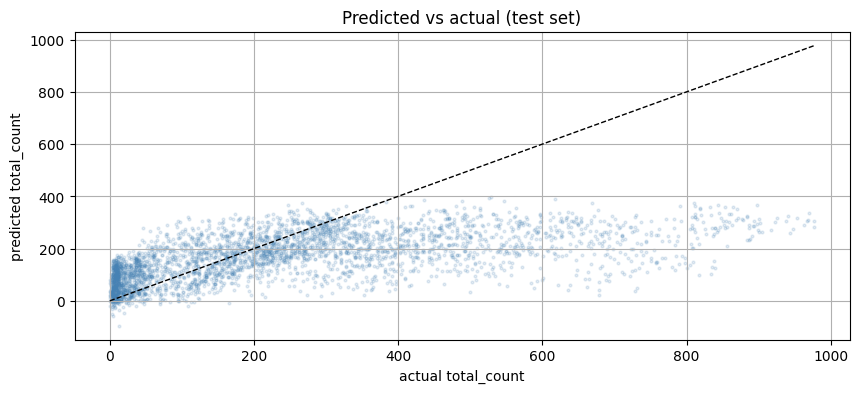

In [7]:
fig, ax = plt.subplots()
lo, hi = 0, max(y_test.max(), y_pred_test.max())
ax.scatter(y_test, y_pred_test, s=4, alpha=0.15, color="steelblue")
ax.plot([lo, hi], [lo, hi], color="black", linestyle="--", linewidth=1)
ax.set_xlabel("actual total_count")
ax.set_ylabel("predicted total_count")
ax.set_title("Predicted vs actual (test set)")
plt.show()

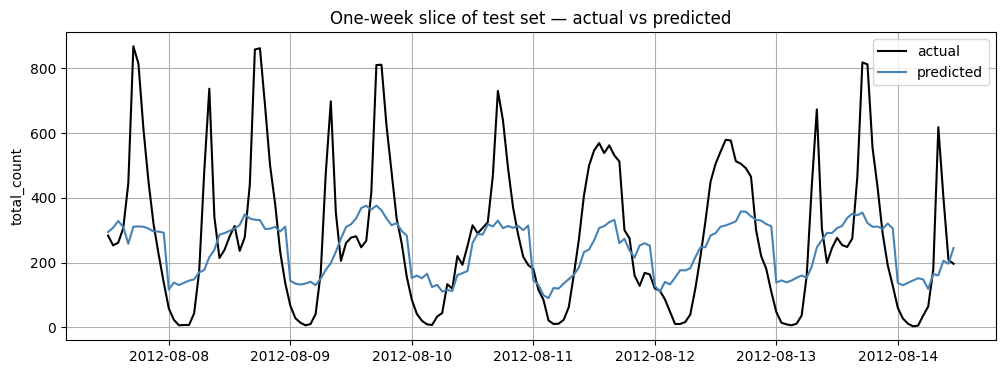

In [8]:
test_idx = df.iloc[split_idx:].reset_index(drop=True)
window = test_idx.iloc[:24 * 7].index

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(test_idx.loc[window, "datetime"], y_test.iloc[window].values, label="actual", color="black")
ax.plot(test_idx.loc[window, "datetime"], y_pred_test[window], label="predicted", color="steelblue")
ax.set_title("One-week slice of test set — actual vs predicted")
ax.set_ylabel("total_count")
ax.legend()
plt.show()

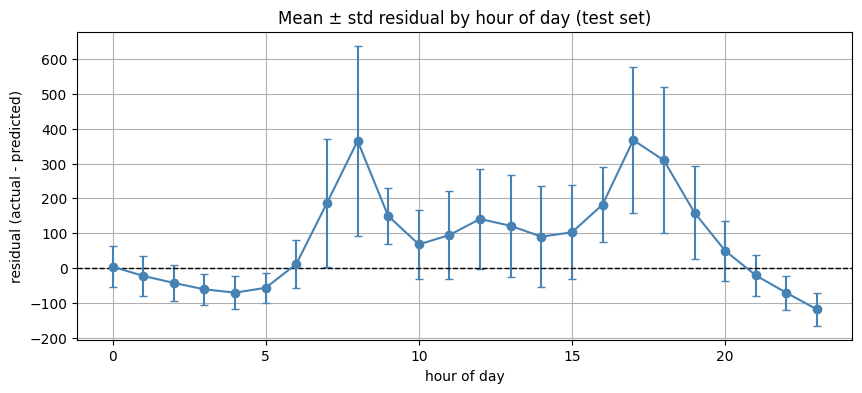

In [9]:
residuals = y_test.values - y_pred_test
by_hour = pd.DataFrame({"hour": X_test["hour"].values, "residual": residuals})
agg = by_hour.groupby("hour")["residual"].agg(["mean", "std"])

fig, ax = plt.subplots()
ax.errorbar(agg.index, agg["mean"], yerr=agg["std"], marker="o", capsize=3, color="steelblue")
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("hour of day")
ax.set_ylabel("residual (actual - predicted)")
ax.set_title("Mean ± std residual by hour of day (test set)")
plt.show()

**What the diagnostics show.**

- The predicted-vs-actual cloud is broad and clipped: the model **cannot predict near-zero or near-max demand** — its predictions cluster around the mean and shrink the extremes. Notably, some predictions go negative (no clipping is applied), which is impossible for a count.
- The one-week overlay confirms the EDA prediction: the linear baseline tracks the *daily average* well but **flattens the commute peaks**. Mornings and evenings on weekdays are systematically under-predicted; nights are over-predicted.
- The residuals-by-hour plot makes that quantitative: residuals at 8 AM and 5–6 PM are large and positive (under-prediction), residuals at 2–5 AM are negative (over-prediction). This is the bimodal `hour × is_weekend` interaction that a plain additive linear model cannot represent.

## 7. Baseline summary

**Result.** A `LinearRegression` on the minimal feature set (after dropping `time_of_day` and `perceived_temperature_c` for collinearity) established a reproducible reference point.

| Split | RMSE | MAE | R² |
|---|---|---|---|
| Train | 134.23 | 98.65 | 0.354 |
| Test  | 199.76 | 134.91 | 0.179 |

Against a target mean of ~190 rentals/hour, test MAE of 135 means the average prediction is off by roughly two-thirds of the mean. The model captures *direction* — temperature up, demand up; rain, demand down — but not *shape*.

**Train/test gap.** R² drops from 0.35 (train) to 0.18 (test). This is exactly the failure mode flagged in the EDA — the test set covers Aug–Dec 2012 (the highest-demand period of the dataset, and one the model has never seen at that scale because 2012 ramps up steeply on 2011). With no trend/year feature, the linear baseline has no way to extrapolate the growth.

**Known failure modes**, all consistent with what the EDA predicted:
1. The bimodal weekday commute curve cannot be expressed as a linear function of `hour`.
2. The `hour × is_weekend` interaction is not in the feature set — the model only learns marginal effects.
3. There is no trend/year feature, so growth in 2012 is partially absorbed by `temperature_c` and partially shows up as the train/test R² gap above.
4. The unbounded linear predictor occasionally outputs negative counts.

**What this notebook is not.** It deliberately stops short of:
- Feature engineering (cyclic encoding of `hour`, interaction terms, `month`/`year` features, `log1p` on the target).
- Trying non-linear models (Ridge, GradientBoosting, XGBoost) that would address the bimodality natively.
- Integration of the modelling step into the Dagster pipeline.

Those are deferred to a separate model-improvement notebook and a follow-up pipeline change.